# Chesapeake Bay Nutrient Classes — Tutorial: OlmoEarth Embeddings + Random Forest

A practitioner-facing tutorial for predicting the 4-tier (Q1–Q4) TN load class at each station-month using a Random Forest classifier. Mirrors Part A of the [OlmoEarth tutorial](https://colab.research.google.com/drive/1JnhFn0IfDJEn49S4sKuCS-mv_b4T2tU0) (frozen-encoder embeddings → simple classifier), adapted for tabular nutrient targets.

This notebook ships with two paths:

1. **Executable baseline (this notebook).** Trains a Random Forest on the dataset's *tabular* features (lat/lon/HUC/year/month) — quick to run, no GPU required, establishes a defensible accuracy floor.
2. **Recipe for OlmoEarth embeddings.** Documented but not executed here, since extracting OlmoEarth embeddings requires Sentinel-2 imagery + GPU. The drop-in code path shows how to swap embeddings for the tabular feature matrix in the same RF pipeline.

## What You'll Learn

- Why frozen-encoder embeddings + a simple downstream classifier is the recommended starting workflow
- How to set up a *spatial* train/validation split that prevents geographic leakage (mirrors the OlmoEarth tutorial)
- How to train and evaluate a Random Forest on the load-class target
- How to read a confusion matrix and per-class report for an ordinal-class problem
- How to upgrade the baseline by swapping tabular features for OlmoEarth embeddings

## Why

Embeddings + RF is a *fast iteration loop* that lets a CEE researcher validate signal-to-noise ratio in their target before committing to longer fine-tuning runs. Even with a tabular feature baseline (no satellite data), the workflow demonstrates the metrics, splits, and evaluation patterns that carry over directly when real OlmoEarth embeddings are plugged in.

## Requirements

- Python 3.11
- `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `datasets` (see `requirements.txt`)
- ~2 minute runtime, no GPU
- For the OlmoEarth-embedding upgrade path (Section 6): GPU + Sentinel-2 access (e.g., Planetary Computer)

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, balanced_accuracy_score)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

CLASS_LABELS = {0: 'Q1 (low)', 1: 'Q2', 2: 'Q3', 3: 'Q4 (high)'}
RANDOM_STATE = 42

## 1. Load and prepare the dataset

Use TN class as the prediction target. Drop the ~10% of rows where TP/sediment are missing (TN itself has no missing values), so all comparisons are on the same row population.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()
df = df.dropna(subset=['tn_load', 'tn_load_class']).reset_index(drop=True)
df['tn_load_class'] = df['tn_load_class'].astype(int)
print(f"Working set: {len(df):,} rows | {df['STAID'].nunique()} stations")
print(f"Target class distribution: {dict(df['tn_load_class'].value_counts().sort_index())}")

Working set: 14,166 rows | 121 stations
Target class distribution: {0: np.int64(1409), 1: np.int64(2118), 2: np.int64(7070), 3: np.int64(3569)}


## 2. Spatial train/validation split (prevents leakage)

Same approach as the OlmoEarth tutorial: split *by station geography* rather than randomly across rows. A random split would put records from the same station in both train and val, leaking station-specific signals. Splitting at the median longitude (west = train, east = val) makes the val set genuinely held-out.

In [3]:
median_lon = df['longitude'].median()
train_mask = df['longitude'] < median_lon
val_mask   = ~train_mask

print(f"Median longitude split: {median_lon:.3f}")
print(f"  train (west): {train_mask.sum():,} rows  |  {df.loc[train_mask, 'STAID'].nunique()} stations")
print(f"  val   (east): {val_mask.sum():,} rows  |  {df.loc[val_mask, 'STAID'].nunique()} stations")
print()
print("Class balance — train vs val:")
balance = pd.DataFrame({
    'train': df.loc[train_mask, 'tn_load_class'].value_counts(normalize=True).sort_index(),
    'val':   df.loc[val_mask,   'tn_load_class'].value_counts(normalize=True).sort_index(),
}).round(3)
balance.index = [CLASS_LABELS[i] for i in balance.index]
balance

Median longitude split: -77.217
  train (west): 7,023 rows  |  60 stations
  val   (east): 7,143 rows  |  61 stations

Class balance — train vs val:


,train,val
Q1 (low),0.082,0.116
Q2,0.189,0.111
Q3,0.544,0.455
Q4 (high),0.185,0.318


## 3. Tabular feature baseline

The features below are intentionally simple. They encode location (lat/lon/HUC/state) and time (year/month). They do **not** include the load values themselves (which would be circular) or the other-pollutant load classes (which would be cross-target leakage). This is the honest baseline a Random Forest can achieve from station identity + time alone, before any satellite-derived signal.

In [4]:
FEATURE_COLS = ['latitude', 'longitude', 'huc', 'state_code', 'Year', 'Month']

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, 'tn_load_class'].values
X_val   = df.loc[val_mask,   FEATURE_COLS].values
y_val   = df.loc[val_mask,   'tn_load_class'].values

print(f"Feature matrix shape: train={X_train.shape}, val={X_val.shape}")
print(f"Features: {FEATURE_COLS}")

Feature matrix shape: train=(7023, 6), val=(7143, 6)
Features: ['latitude', 'longitude', 'huc', 'state_code', 'Year', 'Month']


## 4. Train the Random Forest

Same hyperparameters used as a reasonable first guess for a 4-class problem with mixed feature scales (Random Forests are scale-invariant, so no standardization needed). For OlmoEarth embedding inputs you'd typically standardize first — see Section 6.

In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

preds = rf.predict(X_val)
acc       = accuracy_score(y_val, preds)
bal_acc   = balanced_accuracy_score(y_val, preds)
random_baseline = 1 / 4  # 4 uniform classes

print(f"Validation accuracy:           {acc*100:.2f}%")
print(f"Balanced accuracy (per-class): {bal_acc*100:.2f}%")
print(f"Random-guess baseline:         {random_baseline*100:.2f}%")
print(f"Lift over random:              {(acc/random_baseline):.2f}x")

Validation accuracy:           40.81%
Balanced accuracy (per-class): 42.15%
Random-guess baseline:         25.00%
Lift over random:              1.63x


## 5. Evaluation — confusion matrix and per-class report

For an *ordinal* class target, the confusion matrix should ideally show errors near the diagonal (Q1↔Q2, Q3↔Q4) rather than across (Q1↔Q4). Off-diagonal mass on the corners indicates the classifier is missing the loading magnitude entirely.

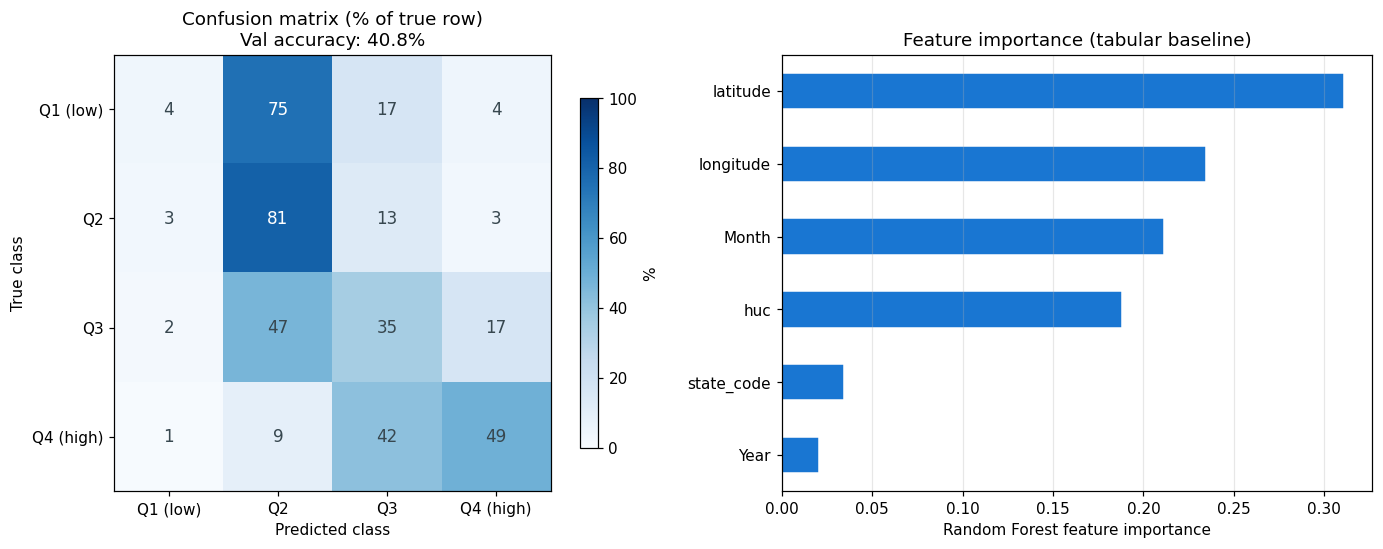


Classification report:
              precision    recall  f1-score   support

    Q1 (low)      0.242     0.039     0.066       831
          Q2      0.216     0.811     0.341       794
          Q3      0.489     0.348     0.406      3250
   Q4 (high)      0.647     0.489     0.557      2268

    accuracy                          0.408      7143
   macro avg      0.398     0.422     0.343      7143
weighted avg      0.480     0.408     0.407      7143



In [6]:
cm = confusion_matrix(y_val, preds, normalize='true') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(4)); ax.set_xticklabels([CLASS_LABELS[i] for i in range(4)])
ax.set_yticks(range(4)); ax.set_yticklabels([CLASS_LABELS[i] for i in range(4)])
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix (% of true row)\nVal accuracy: {acc*100:.1f}%")
for i in range(4):
    for j in range(4):
        color = 'white' if cm[i, j] > 50 else '#37474f'
        ax.text(j, i, f"{cm[i, j]:.0f}", ha='center', va='center', color=color, fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8, label='%')

ax = axes[1]
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', ax=ax, color='#1976d2', edgecolor='white')
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Feature importance (tabular baseline)")
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_val, preds,
                             target_names=[CLASS_LABELS[i] for i in range(4)], digits=3))

**Reading the matrix.** A diagonal-heavy confusion matrix means the classifier captures the ordinal structure (loadings are roughly correctly tiered). Off-diagonal mass concentrated near the diagonal (Q2 predicted as Q1 or Q3) is acceptable; mass on the far corners (Q1 predicted as Q4) indicates real failures. Compare the per-class precision and recall: a class where recall ≪ precision means the model rarely picks that class but is right when it does (under-prediction); the reverse means over-prediction.

## 6. Recipe: upgrading to OlmoEarth embeddings

The tabular baseline above is a floor. The expected upgrade path swaps the 6 tabular features for ~256–768-dimensional OlmoEarth embeddings extracted from a Sentinel-2 time series at each station's location. Documented but not executed here.

### Step 1 — Install OlmoEarth + rslearn

```python
!pip install -q olmoearth_pretrain rslearn 'jsonargparse[signatures]>=4.27.7'
```

### Step 2 — Acquire Sentinel-2 imagery for each station

For each `(STAID, Year)` pair in the dataset, query a Sentinel-2 source (e.g., Microsoft Planetary Computer, Element 84, or Sentinel Hub) for a 12-month time series centered on a small window (~5 km × 5 km) around the station's lat/lon.

```python
import planetary_computer
import pystac_client
# query stac, materialize 12 monthly cloud-free composites per station
```

### Step 3 — Extract embeddings with the frozen OlmoEarth encoder

```python
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.data.normalize import load_computed_config

model = load_model_from_id(ModelID.OLMOEARTH_NANO_V1)
norm_config = load_computed_config()
model.eval()

# For each station-year sample, normalize the Sentinel-2 stack and run the encoder
embeddings = []
for sample in samples:
    normalized = normalize_sample(sample, norm_config)
    with torch.no_grad():
        emb = model.encode(normalized).mean(dim=(2, 3))  # global pool over spatial tokens
    embeddings.append(emb.cpu().numpy())
embeddings = np.stack(embeddings)  # shape: (n_samples, embedding_dim)
```

### Step 4 — Standardize, then plug into the same RF pipeline

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_emb = scaler.fit_transform(embeddings[train_mask])
X_val_emb   = scaler.transform(embeddings[val_mask])

rf_emb = RandomForestClassifier(n_estimators=300, max_depth=14,
                                  min_samples_leaf=3, n_jobs=-1,
                                  random_state=RANDOM_STATE)
rf_emb.fit(X_train_emb, y_train)
preds_emb = rf_emb.predict(X_val_emb)
print(f"OlmoEarth-embedding RF accuracy: {accuracy_score(y_val, preds_emb)*100:.2f}%")
```

The OlmoEarth tutorial reports ~70% accuracy for the embeddings + linear-probe combination on a 9-class land-cover task. For our 4-class nutrient-load problem, the expected lift over the tabular baseline depends on how strongly the local satellite signal (vegetation health, agricultural intensity, urbanization, riparian buffer condition) correlates with watershed nutrient delivery — typically a meaningful boost for the agricultural sub-basins, smaller for the highly urbanized ones.

## Takeaways

- **The tabular baseline is the honest floor.** It uses only station identity and time. Anything OlmoEarth embeddings add on top is the value the satellite signal contributes to nutrient-load prediction.
- **Spatial splits are mandatory.** Random splits inflate accuracy because per-station means leak across the train/val boundary. Always split by geography (or by station holdout) for spatial-temporal datasets.
- **Confusion-matrix structure tells you what's failing.** Near-diagonal errors are acceptable for an ordinal target; corner errors aren't. Use this to diagnose under- or over-prediction by class before retraining.
- **Embeddings + simple classifier > end-to-end fine-tuning** for the *first* iteration. Fast feedback, low compute, no risk of overfit. Reach for fine-tuning only after the embedding baseline saturates.
- **The pipeline is plug-replace.** Swap `X_train`/`X_val` for OlmoEarth embeddings and the rest of this notebook (split, training, evaluation, confusion matrix) carries over unchanged.

## Cross-references

- **`01_demo_quick_look.ipynb`** — schema, station ranking, threshold table for the load classes.
- **`02_data_prep_reproduce.ipynb`** — how the *_load and *_class columns are constructed (and how to verify them).
- **`04_analysis_results.ipynb`** — cross-station synthesis: persistence, sub-basin contributions, seasonality.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*